# Downscaling Temperature at GHI for **NYC Tristate** area

## Info:
This notebook includes the code to run a deep-learning based downscaling model using the dl4ds library on the SWDOWN variable. This variable, downward short wave flux at ground surface, is representative of the global horizaontal irradiance variable (GHI). **Currently, this model does NOT include a predictor variable.**

**Variables:**
* DOWNWARD SHORT WAVE FLUX AT GROUND SURFACE (SWDOWN)

**Dataset Resolutions:**
* uWRF (Domain 02): 3-hourly, 3 km
* NAM: 3-hourly, 12 km

**Spatial Coverage:**
* 115,291.16 km²

In [1]:
# Training model with original dimensions
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import dl4d as dds
#import dl4ds as dds
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import models

2025-06-04 13:25:44.177029: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-04 13:25:44.398543: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/compiler/lib/intel64_lin:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/libfabric/lib:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib/release:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib:/software1/intel/2020_

In [2]:
!python --version

Python 3.7.12


In [3]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [4]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [24]:
uwrf_train

<xarray.Dataset>
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (y, x) float32 39.84 39.83 39.82 39.81 ... 42.04 42.03 42.02
    longitude  (y, x) float32 -76.7 -76.67 -76.64 -76.6 ... -71.29 -71.25 -71.22
  * time       (time) datetime64[ns] 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 ...
    PSFC       (time, y, x) float32 ...
    U10        (time, y, x) float32 ...
    V10        (time, y, x) float32 ...
    SWDOWN     (time, y, x) float32 ...
    PBLH       (time, y, x) float32 ...
    HGT        (time, y, x) float32 ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [23]:
nam_train

<xarray.Dataset>
Dimensions:    (time: 2697, y: 40, x: 40)
Coordinates:
  * y          (y) float64 1.219e+04 2.438e+04 3.657e+04 ... 4.754e+05 4.876e+05
  * x          (x) float64 3.292e+05 3.413e+05 3.535e+05 ... 7.924e+05 8.046e+05
    latitude   (y, x) float64 39.22 39.2 39.19 39.17 ... 42.69 42.67 42.66 42.64
    longitude  (y, x) float64 -77.09 -76.96 -76.82 ... -71.17 -71.03 -70.89
  * time       (time) datetime64[ns] 2019-01-01 ... 2019-04-14T03:00:00
Data variables:
    T2         (time, y, x) float32 ...
    PSFC       (time, y, x) float32 ...
    U10        (time, y, x) float32 ...
    V10        (time, y, x) float32 ...
    SWDOWN     (time, y, x) float32 ...
    PBLH       (time, y, x) float32 ...
    HGT        (time, y, x) float32 ...
Attributes:
    Conventions:          CF-1.0
    History:              created by wgrib2
    GRIB2_grid_template:  30

In [8]:
nam_train['time'][15]

<xarray.DataArray 'time' ()>
array('2019-01-02T18:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2019-01-02T18:00:00
Attributes:
    long_name:                   verification time generated by wgrib2 functi...
    reference_time:              1546387200.0
    reference_time_type:         3
    reference_date:              2019.01.02 00:00:00 UTC
    reference_time_description:  forecast or accumulated, reference date is f...
    time_step_setting:           auto
    time_step:                   0.0

In [9]:
uwrf_train['time'][15]

<xarray.DataArray 'time' ()>
array('2019-01-02T18:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2019-01-02T18:00:00
Attributes:
    FieldType:    104
    MemoryOrder:  0  
    description:  minutes since 2019-01-01 00:00:00
    stagger:

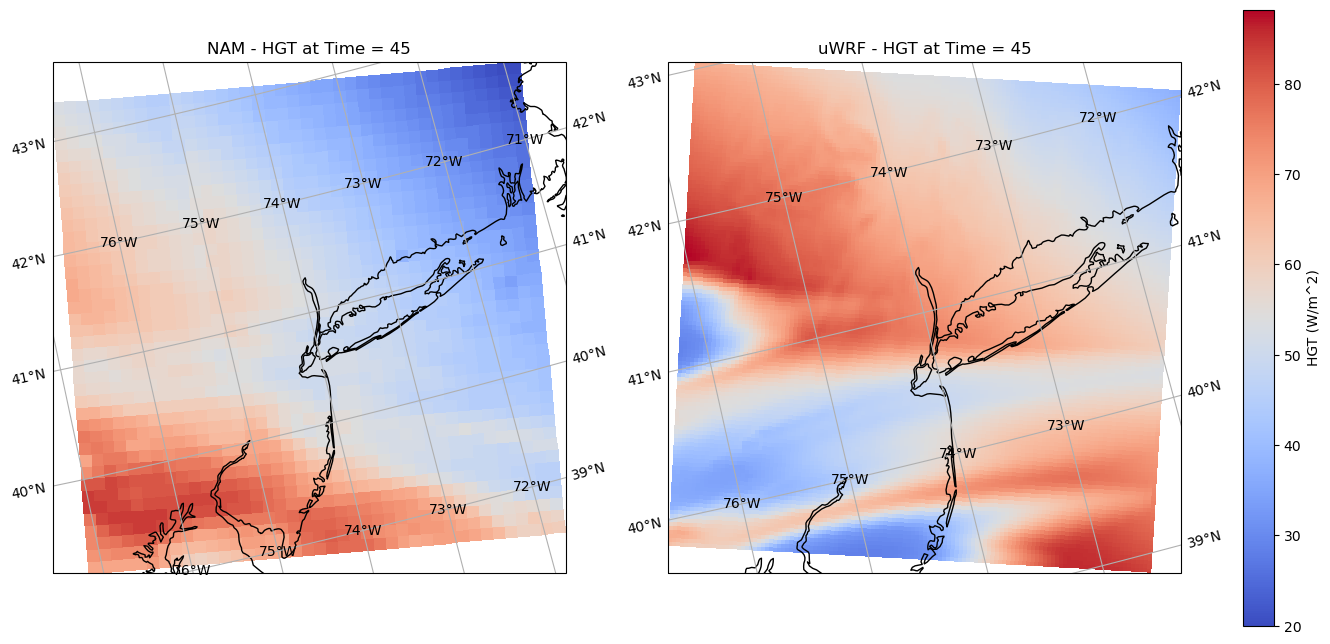

In [33]:
#comparing!
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr

nam = nam_train.SWDOWN
uwrf = uwrf_train.SWDOWN
t_idx = 45


# Extract values
lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
ghi_nam = nam[t_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
ghi_uwrf = uwrf[t_idx,:,:].values

# Determine common color limits
vmin = min(ghi_nam.min(), ghi_uwrf.min())
vmax = max(ghi_nam.max(), ghi_uwrf.max())

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im1 = axes[0].pcolormesh(lon_nam, lat_nam, ghi_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title(f'NAM - HGT at Time = {t_idx}')
axes[0].coastlines()
axes[0].gridlines(draw_labels=True)

# Plot uWRF
im2 = axes[1].pcolormesh(lon_uwrf, lat_uwrf, ghi_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].set_title(f'uWRF - HGT at Time = {t_idx}')
axes[1].coastlines()
axes[1].gridlines(draw_labels=True)

# Add single colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('HGT (W/m^2)')


plt.show()